# NLP Project: Comparison of Text Feature Representations and Classification Models for Fake News Detection


This notebook compares:
- classic text variants with `BoW`, `TF-IDF`, and `TF-IDF log`
- one standard `Word2Vec` variant
- one standard `BERT` variant

It includes the model families:
- `Naive Bayes`
- `Logistic Regression`
- `Random Forest`
- `SVM`
- `XGBoost`
- `Neural Network`



In [6]:
# ---------------------------------------------------------
# CELL 1: IMPORTS AND GENERAL SETTINGS
# ---------------------------------------------------------
# We import all the libraries we need for:
# - data handling
# - preprocessing
# - machine learning models
# - tuning
# - plotting

import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# One seed for reproducibility.
SEED = 2324
np.random.seed(SEED)

# Hide warnings to keep notebook output cleaner.
warnings.filterwarnings("ignore")

# Seaborn plot style.
sns.set_theme(style="whitegrid", context="talk")

In [7]:
# ---------------------------------------------------------
# CELL 2: OPTIONAL INSTALLS FOR EMBEDDINGS
# ---------------------------------------------------------
# If you are in Colab or in a fresh environment, uncomment this.

!pip install gensim transformers torch sentencepiece

In [8]:
# ---------------------------------------------------------
# CELL 3: EMBEDDING LIBRARIES
# ---------------------------------------------------------
# These are only needed for Word2Vec and BERT.

from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
import torch

# Use GPU if available, otherwise CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", DEVICE)

Torch device: cpu


In [9]:
# ---------------------------------------------------------
# CELL 4: LOAD TRAINING AND TEST DATA
# ---------------------------------------------------------
# The training file has:
# - label
# - headline
#
# The test file has unlabeled headlines for final prediction.

data = pd.read_csv(
    "training_data_lowercase.csv",
    sep="\t",
    header=None,
    names=["label", "headline"]
)

test_data = pd.read_csv(
    "testing_data_lowercase_nolabels.csv",
    sep="\t",
    header=None,
    names=["placeholder", "headline"],
    dtype=str
)

# Make sure labels are numeric.
data["label"] = data["label"].astype(int)

print(data.head(3))
print(data.shape)
print(test_data.head(3))
print(test_data.shape)

   label                                           headline
0      0  donald trump sends out embarrassing new year‚s...
1      0  drunk bragging trump staffer started russian c...
2      0  sheriff david clarke becomes an internet joke ...
(34152, 2)
  placeholder                                           headline
0           2  copycat muslim terrorist arrested with assault...
1           2  wow! chicago protester caught on camera admits...
2           2   germany's fdp look to fill schaeuble's big shoes
(9984, 2)


In [10]:
# ---------------------------------------------------------
# CELL 5: PREPROCESSING FUNCTIONS
# ---------------------------------------------------------
# Here we define:
# - classic sparse-text preprocessing
# - light Word2Vec cleaning
# - very light BERT cleaning

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

for resource in ["stopwords", "punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

stop_words = set(stopwords.words("english"))
simple_stop_words = set(ENGLISH_STOP_WORDS)
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.replace("'", "")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\b[a-z]\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_stopwords_split(text):
    if not text:
        return ""
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

def remove_stopwords_token(text):
    if not text:
        return ""
    words = word_tokenize(text)
    words = [word for word in words if word.lower() not in stop_words]
    return " ".join(words)

def lemmatize_text_split(text):
    if not text:
        return ""
    return " ".join(lemmatizer.lemmatize(word) for word in text.split())

def lemmatize_text_token(text):
    if not text:
        return ""
    return " ".join(lemmatizer.lemmatize(word) for word in word_tokenize(text))

def stem_text_split(text):
    if not text:
        return ""
    return " ".join(stemmer.stem(word) for word in text.split())

def stem_text_token(text):
    if not text:
        return ""
    return " ".join(stemmer.stem(word) for word in word_tokenize(text))

def clean_for_word2vec(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.replace("'", "")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_for_bert(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def split_words(text):
    if not text:
        return []
    return text.split()

In [11]:
# ---------------------------------------------------------
# CELL 6: CREATE ALL TEXT VARIANTS
# ---------------------------------------------------------
# Classic sparse variants:
# - split_lemma
# - split_stem
# - token_lemma
# - token_stem
#
# Embedding variants:
# - word2vec_standard
# - bert_standard

data["headline_clean"] = data["headline"].apply(preprocess_text)
test_data["headline_clean"] = test_data["headline"].apply(preprocess_text)

data["split_lemma"] = data["headline_clean"].apply(remove_stopwords_split).apply(lemmatize_text_split)
data["split_stem"] = data["headline_clean"].apply(remove_stopwords_split).apply(stem_text_split)
data["token_lemma"] = data["headline_clean"].apply(remove_stopwords_token).apply(lemmatize_text_token)
data["token_stem"] = data["headline_clean"].apply(remove_stopwords_token).apply(stem_text_token)

test_data["split_lemma"] = test_data["headline_clean"].apply(remove_stopwords_split).apply(lemmatize_text_split)
test_data["split_stem"] = test_data["headline_clean"].apply(remove_stopwords_split).apply(stem_text_split)
test_data["token_lemma"] = test_data["headline_clean"].apply(remove_stopwords_token).apply(lemmatize_text_token)
test_data["token_stem"] = test_data["headline_clean"].apply(remove_stopwords_token).apply(stem_text_token)

data["word2vec_standard"] = data["headline"].apply(clean_for_word2vec).apply(split_words)
test_data["word2vec_standard"] = test_data["headline"].apply(clean_for_word2vec).apply(split_words)

data["bert_standard"] = data["headline"].apply(clean_for_bert)
test_data["bert_standard"] = test_data["headline"].apply(clean_for_bert)

print(data[["headline", "split_lemma", "token_lemma", "word2vec_standard", "bert_standard"]].head(2))

                                            headline  \
0  donald trump sends out embarrassing new year‚s...   
1  drunk bragging trump staffer started russian c...   

                                         split_lemma  \
0  donald trump sends embarrassing new year eve m...   
1  drunk bragging trump staffer started russian c...   

                                         token_lemma  \
0  donald trump sends embarrassing new year eve m...   
1  drunk bragging trump staffer started russian c...   

                                   word2vec_standard  \
0  [donald, trump, sends, out, embarrassing, new,...   
1  [drunk, bragging, trump, staffer, started, rus...   

                                       bert_standard  
0  donald trump sends out embarrassing new year‚s...  
1  drunk bragging trump staffer started russian c...  


In [12]:
# ---------------------------------------------------------
# CELL 7: TRAIN / VALIDATION SPLIT
# ---------------------------------------------------------
# We split once and reuse the same split for all experiments.

train_idx, val_idx = train_test_split(
    data.index,
    test_size=0.2,
    random_state=SEED,
    stratify=data["label"]
)

y_train = data.loc[train_idx, "label"]
y_val = data.loc[val_idx, "label"]
y_full = data["label"]

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))

Train size: 27321
Validation size: 6831


In [13]:
# ---------------------------------------------------------
# CELL 8: PREPARE CLASSIC TEXT FOR THE SPARSE MODELS
# ---------------------------------------------------------
# These remain as strings because vectorizers will convert them later.

classic_variant_splits = {
    "split_lemma": {
        "X_train": data.loc[train_idx, "split_lemma"],
        "X_val": data.loc[val_idx, "split_lemma"],
        "X_full": data["split_lemma"],
        "X_test": test_data["split_lemma"],
    },
    "split_stem": {
        "X_train": data.loc[train_idx, "split_stem"],
        "X_val": data.loc[val_idx, "split_stem"],
        "X_full": data["split_stem"],
        "X_test": test_data["split_stem"],
    },
    "token_lemma": {
        "X_train": data.loc[train_idx, "token_lemma"],
        "X_val": data.loc[val_idx, "token_lemma"],
        "X_full": data["token_lemma"],
        "X_test": test_data["token_lemma"],
    },
    "token_stem": {
        "X_train": data.loc[train_idx, "token_stem"],
        "X_val": data.loc[val_idx, "token_stem"],
        "X_full": data["token_stem"],
        "X_test": test_data["token_stem"],
    },
}

print(classic_variant_splits.keys())

dict_keys(['split_lemma', 'split_stem', 'token_lemma', 'token_stem'])


In [14]:
# ---------------------------------------------------------
# CELL 9: HELPER FUNCTIONS FOR EMBEDDINGS
# ---------------------------------------------------------
# average_vectors() creates one Word2Vec vector per headline.
# encode_with_bert() creates one BERT vector per headline.

def average_vectors(token_lists, model, vector_size):
    rows = []
    for tokens in token_lists:
        valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
        if len(valid_vectors) > 0:
            rows.append(np.mean(valid_vectors, axis=0))
        else:
            rows.append(np.zeros(vector_size))
    return np.vstack(rows)

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed_embeddings = masked_embeddings.sum(dim=1)
    token_counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed_embeddings / token_counts

def encode_with_bert(text_list, tokenizer, model, batch_size=32, max_length=64):
    rows = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(text_list), batch_size):
            batch_text = text_list[start:start + batch_size]
            encoded = tokenizer(
                batch_text,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
            outputs = model(**encoded)
            pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
            rows.append(pooled.cpu().numpy())
    return np.vstack(rows)

In [15]:
# ---------------------------------------------------------
# CELL 10: BUILD WORD2VEC FEATURES
# ---------------------------------------------------------
# We train one Word2Vec model on the training split for validation work,
# and another on the full data for final test prediction.

vector_size = 100

train_w2v_model = Word2Vec(
    sentences=data.loc[train_idx, "word2vec_standard"].tolist(),
    vector_size=vector_size,
    window=5,
    min_count=1,
    workers=1,
    sg=1,
    seed=SEED,
)

full_w2v_model = Word2Vec(
    sentences=data["word2vec_standard"].tolist(),
    vector_size=vector_size,
    window=5,
    min_count=1,
    workers=1,
    sg=1,
    seed=SEED,
)

X_train_word2vec = average_vectors(data.loc[train_idx, "word2vec_standard"].tolist(), train_w2v_model, vector_size)
X_val_word2vec = average_vectors(data.loc[val_idx, "word2vec_standard"].tolist(), train_w2v_model, vector_size)
X_full_word2vec = average_vectors(data["word2vec_standard"].tolist(), full_w2v_model, vector_size)
X_test_word2vec = average_vectors(test_data["word2vec_standard"].tolist(), full_w2v_model, vector_size)

print(X_train_word2vec.shape, X_val_word2vec.shape)

(27321, 100) (6831, 100)


In [16]:
# ---------------------------------------------------------
# CELL 11: BUILD BERT FEATURES
# ---------------------------------------------------------
# We use one standard pretrained model.

bert_model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to(DEVICE)

X_train_bert = encode_with_bert(data.loc[train_idx, "bert_standard"].tolist(), tokenizer, bert_model)
X_val_bert = encode_with_bert(data.loc[val_idx, "bert_standard"].tolist(), tokenizer, bert_model)
X_full_bert = encode_with_bert(data["bert_standard"].tolist(), tokenizer, bert_model)
X_test_bert = encode_with_bert(test_data["bert_standard"].tolist(), tokenizer, bert_model)

print(X_train_bert.shape, X_val_bert.shape)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(27321, 768) (6831, 768)


In [17]:
# ---------------------------------------------------------
# CELL 12: SMALL HELPER FOR RANDOM SEARCH
# ---------------------------------------------------------
# We use RandomizedSearchCV to reduce runtime.
# This helper keeps n_iter from becoming larger than the real number of combinations.

def count_param_combinations(param_grid):
    total = 1
    for values in param_grid.values():
        total *= len(values)
    return total

def choose_n_iter(param_grid, max_iter=8):
    total = count_param_combinations(param_grid)
    return min(max_iter, total)

In [18]:
# ---------------------------------------------------------
# CELL 13: RUN THE CLASSIC SPARSE-TEXT EXPERIMENTS
# ---------------------------------------------------------
# Feature types:
# - bow
# - tfidf
# - tfidf_log
#
# Models:
# - Naive Bayes
# - Logistic Regression
# - Random Forest
# - SVM
# - XGBoost
# - Neural Network

search_results = []
best_estimators = {}

classic_variant_names = ["split_lemma", "split_stem", "token_lemma", "token_stem"]
sparse_feature_names = ["bow", "tfidf", "tfidf_log"]
sparse_model_names = ["Naive Bayes", "Logistic Regression", "Random Forest", "SVM", "XGBoost", "Neural Network"]

for variant_name in classic_variant_names:
    X_train_text = classic_variant_splits[variant_name]["X_train"]
    X_val_text = classic_variant_splits[variant_name]["X_val"]

    for feature_name in sparse_feature_names:
        if feature_name == "bow":
            vectorizer = CountVectorizer()
        elif feature_name == "tfidf":
            vectorizer = TfidfVectorizer(sublinear_tf=False)
        else:
            vectorizer = TfidfVectorizer(sublinear_tf=True)

        vectorizer_params = {
            "vectorizer__max_features": [3000, 5000],
            "vectorizer__min_df": [1, 2],
            "vectorizer__max_df": [0.8, 1.0],
        }

        for model_name in sparse_model_names:
            if model_name == "Naive Bayes":
                model = MultinomialNB()
                model_params = {"model__alpha": [0.5, 1.0]}
            elif model_name == "Logistic Regression":
                model = LogisticRegression(max_iter=1000, random_state=SEED)
                model_params = {"model__C": [0.1, 1, 10]}
            elif model_name == "Random Forest":
                model = RandomForestClassifier(random_state=SEED, n_jobs=-1)
                model_params = {"model__n_estimators": [100, 200], "model__max_depth": [None, 20]}
            elif model_name == "SVM":
                model = LinearSVC(random_state=SEED)
                model_params = {"model__C": [0.1, 1, 10]}
            elif model_name == "XGBoost":
                model = XGBClassifier(eval_metric="logloss", random_state=SEED)
                model_params = {
                    "model__n_estimators": [100, 200],
                    "model__max_depth": [4, 6],
                    "model__learning_rate": [0.1, 0.2],
                }
            else:
                model = MLPClassifier(max_iter=300, random_state=SEED)
                model_params = {
                    "model__hidden_layer_sizes": [(128,), (128, 64)],
                    "model__alpha": [0.0001, 0.001],
                }

            pipeline = Pipeline([
                ("vectorizer", vectorizer),
                ("model", model)
            ])

            param_grid = {}
            param_grid.update(vectorizer_params)
            param_grid.update(model_params)

            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grid,
                n_iter=choose_n_iter(param_grid, max_iter=8),
                cv=3,
                scoring="accuracy",
                n_jobs=-1,
                random_state=SEED
            )
            search.fit(X_train_text, y_train)

            best_model = search.best_estimator_
            y_pred_train = best_model.predict(X_train_text)
            y_pred_val = best_model.predict(X_val_text)

            best_estimators[(variant_name, feature_name, model_name)] = best_model

            search_results.append({
                "feature_family": "sparse_text",
                "variant": variant_name,
                "feature": feature_name,
                "model": model_name,
                "train_accuracy": accuracy_score(y_train, y_pred_train),
                "val_accuracy": accuracy_score(y_val, y_pred_val),
                "best_cv_accuracy": search.best_score_,
                "best_params": search.best_params_,
            })

In [19]:
# ---------------------------------------------------------
# CELL 14: RUN THE EMBEDDING EXPERIMENTS
# ---------------------------------------------------------
# Embedding variants:
# - word2vec_standard
# - bert_standard
#
# Models:
# - Naive Bayes (GaussianNB here)
# - Logistic Regression
# - Random Forest
# - SVM
# - XGBoost
# - Neural Network

embedding_variant_names = ["word2vec_standard", "bert_standard"]
embedding_model_names = ["Naive Bayes", "Logistic Regression", "Random Forest", "SVM", "XGBoost", "Neural Network"]

for variant_name in embedding_variant_names:
    if variant_name == "word2vec_standard":
        X_train_embed = X_train_word2vec
        X_val_embed = X_val_word2vec
    else:
        X_train_embed = X_train_bert
        X_val_embed = X_val_bert

    for model_name in embedding_model_names:
        if model_name == "Naive Bayes":
            model = GaussianNB()
            model_params = {"model__var_smoothing": [1e-9, 1e-8, 1e-7]}
            use_scaler = False
        elif model_name == "Logistic Regression":
            model = LogisticRegression(max_iter=1000, random_state=SEED)
            model_params = {"model__C": [0.1, 1, 10]}
            use_scaler = True
        elif model_name == "Random Forest":
            model = RandomForestClassifier(random_state=SEED, n_jobs=-1)
            model_params = {"model__n_estimators": [100, 200], "model__max_depth": [None, 20]}
            use_scaler = False
        elif model_name == "SVM":
            model = LinearSVC(random_state=SEED)
            model_params = {"model__C": [0.1, 1, 10]}
            use_scaler = True
        elif model_name == "XGBoost":
            model = XGBClassifier(eval_metric="logloss", random_state=SEED)
            model_params = {
                "model__n_estimators": [100, 200],
                "model__max_depth": [4, 6],
                "model__learning_rate": [0.1, 0.2],
            }
            use_scaler = False
        else:
            model = MLPClassifier(max_iter=300, random_state=SEED)
            model_params = {
                "model__hidden_layer_sizes": [(128,), (128, 64)],
                "model__alpha": [0.0001, 0.001],
            }
            use_scaler = True

        if use_scaler:
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", model)
            ])
        else:
            pipeline = Pipeline([
                ("model", model)
            ])

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=model_params,
            n_iter=choose_n_iter(model_params, max_iter=8),
            cv=3,
            scoring="accuracy",
            n_jobs=-1,
            random_state=SEED
        )
        search.fit(X_train_embed, y_train)

        best_model = search.best_estimator_
        y_pred_train = best_model.predict(X_train_embed)
        y_pred_val = best_model.predict(X_val_embed)

        feature_name = "word2vec" if variant_name == "word2vec_standard" else "bert"
        best_estimators[(variant_name, feature_name, model_name)] = best_model

        search_results.append({
            "feature_family": "embedding",
            "variant": variant_name,
            "feature": feature_name,
            "model": model_name,
            "train_accuracy": accuracy_score(y_train, y_pred_train),
            "val_accuracy": accuracy_score(y_val, y_pred_val),
            "best_cv_accuracy": search.best_score_,
            "best_params": search.best_params_,
        })

In [20]:
# ---------------------------------------------------------
# CELL 15: MAIN RESULTS TABLE
# ---------------------------------------------------------
# This shows all pipelines together.

results_df = pd.DataFrame(search_results).sort_values(
    by=["feature_family", "variant", "feature", "val_accuracy", "best_cv_accuracy"],
    ascending=[True, True, True, False, False]
).reset_index(drop=True)

results_df[[
    "feature_family",
    "variant",
    "feature",
    "model",
    "train_accuracy",
    "val_accuracy",
    "best_cv_accuracy",
    "best_params"
]]

,feature_family,variant,feature,model,train_accuracy,val_accuracy,best_cv_accuracy,best_params
0,embedding,bert_standard,bert,Neural Network,1.000000,0.975260,0.969071,"{'model__hidden_layer_sizes': (128,), 'model__..."
1,embedding,bert_standard,bert,Logistic Regression,0.974013,0.968526,0.961971,{'model__C': 0.1}
2,embedding,bert_standard,bert,SVM,0.974891,0.968087,0.959592,{'model__C': 0.1}
3,embedding,bert_standard,bert,XGBoost,1.000000,0.957986,0.950404,"{'model__n_estimators': 200, 'model__max_depth..."
4,embedding,bert_standard,bert,Random Forest,1.000000,0.929878,0.922075,"{'model__n_estimators': 200, 'model__max_depth..."
...,...,...,...,...,...,...,...,...
79,sparse_text,token_stem,tfidf_log,SVM,0.945207,0.928561,0.921782,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."
80,sparse_text,token_stem,tfidf_log,Neural Network,1.000000,0.925780,0.912485,"{'vectorizer__min_df': 2, 'vectorizer__max_fea..."
81,sparse_text,token_stem,tfidf_log,Naive Bayes,0.933860,0.925633,0.918451,"{'vectorizer__min_df': 2, 'vectorizer__max_fea..."
82,sparse_text,token_stem,tfidf_log,Random Forest,1.000000,0.911433,0.904982,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."


In [21]:
# ---------------------------------------------------------
# CELL 16: BEST MODEL INSIDE EACH SETUP
# ---------------------------------------------------------
# A setup means one variant + one feature type.
# We keep the best model inside each setup.

best_by_setup_df = (
    results_df.sort_values(
        by=["feature_family", "variant", "feature", "val_accuracy", "best_cv_accuracy"],
        ascending=[True, True, True, False, False]
    )
    .groupby(["feature_family", "variant", "feature"], as_index=False)
    .first()
)

best_by_setup_df[[
    "feature_family",
    "variant",
    "feature",
    "model",
    "train_accuracy",
    "val_accuracy",
    "best_cv_accuracy",
    "best_params"
]]

,feature_family,variant,feature,model,train_accuracy,val_accuracy,best_cv_accuracy,best_params
0,embedding,bert_standard,bert,Neural Network,1.000000,0.975260,0.969071,"{'model__hidden_layer_sizes': (128,), 'model__..."
1,embedding,word2vec_standard,word2vec,XGBoost,1.000000,0.941004,0.937777,"{'model__n_estimators': 200, 'model__max_depth..."
2,sparse_text,split_lemma,bow,Naive Bayes,0.939717,0.930610,0.925552,"{'vectorizer__min_df': 2, 'vectorizer__max_fea..."
3,sparse_text,split_lemma,tfidf,Logistic Regression,0.973537,0.934270,0.929139,"{'vectorizer__min_df': 2, 'vectorizer__max_fea..."
4,sparse_text,split_lemma,tfidf_log,Logistic Regression,0.973427,0.934270,0.928956,"{'vectorizer__min_df': 2, 'vectorizer__max_fea..."
5,sparse_text,split_stem,bow,SVM,0.954614,0.929147,0.923209,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."
6,sparse_text,split_stem,tfidf,Logistic Regression,0.969986,0.933099,0.928004,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."
7,sparse_text,split_stem,tfidf_log,Logistic Regression,0.970426,0.933245,0.928041,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."
8,sparse_text,token_lemma,bow,Naive Bayes,0.939534,0.930757,0.925918,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."
9,sparse_text,token_lemma,tfidf,Logistic Regression,0.973610,0.934124,0.929029,"{'vectorizer__min_df': 1, 'vectorizer__max_fea..."


In [22]:
# ---------------------------------------------------------
# CELL 17: BEST OVERALL MODEL AND FINAL TEST PREDICTIONS
# ---------------------------------------------------------
# We choose the best validation result across all pipelines.

best_overall_row = results_df.sort_values(by=["val_accuracy", "best_cv_accuracy"], ascending=False).iloc[0]
best_key = (best_overall_row["variant"], best_overall_row["feature"], best_overall_row["model"])
best_pipeline = best_estimators[best_key]

if best_overall_row["feature_family"] == "sparse_text":
    final_model = best_pipeline
    final_model.fit(classic_variant_splits[best_key[0]]["X_full"], y_full)
    y_pred_test_best = final_model.predict(classic_variant_splits[best_key[0]]["X_test"])
    y_pred_val_best = best_pipeline.predict(classic_variant_splits[best_key[0]]["X_val"])
elif best_key[0] == "word2vec_standard":
    final_model = best_pipeline
    final_model.fit(X_full_word2vec, y_full)
    y_pred_test_best = final_model.predict(X_test_word2vec)
    y_pred_val_best = best_pipeline.predict(X_val_word2vec)
else:
    final_model = best_pipeline
    final_model.fit(X_full_bert, y_full)
    y_pred_test_best = final_model.predict(X_test_bert)
    y_pred_val_best = best_pipeline.predict(X_val_bert)

submission_df = pd.DataFrame({"predicted_label": y_pred_test_best})

print("Best overall setup:")
print(best_overall_row[["feature_family", "variant", "feature", "model", "train_accuracy", "val_accuracy", "best_cv_accuracy"]])
print()
print("Best parameters:")
print(best_overall_row["best_params"])
print()
print("Validation classification report:")
print(classification_report(y_val, y_pred_val_best))
print()
print("First 10 test predictions:")
print(submission_df.head(10))

Best overall setup:
feature_family           embedding
variant              bert_standard
feature                       bert
model               Neural Network
train_accuracy                 1.0
val_accuracy               0.97526
best_cv_accuracy          0.969071
Name: 0, dtype: object

Best parameters:
{'model__hidden_layer_sizes': (128,), 'model__alpha': 0.001}

Validation classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3515
           1       1.00      1.00      1.00      3316

    accuracy                           1.00      6831
   macro avg       1.00      1.00      1.00      6831
weighted avg       1.00      1.00      1.00      6831


First 10 test predictions:
   predicted_label
0                0
1                0
2                1
3                0
4                1
5                0
6                1
7                0
8                1
9                1


In [73]:
import pandas as pd

# Read the original test file without modifying it
test_file_original = pd.read_csv(
    "testing_data_lowercase_nolabels.csv",
    sep="\t",
    header=None,
    dtype=str
)

# Make a copy so the original file stays untouched
test_file_with_predictions = test_file_original.copy()

# Replace the placeholder column with the model predictions
test_file_with_predictions[0] = y_pred_test_best

# Save as a NEW CSV file
output_file = "testing_data_with_predictions.csv"
test_file_with_predictions.to_csv(output_file, index=False, header=False)

print("New file created:")
print(output_file)
print()
print("Saved in the current working directory.")
print()
print(test_file_with_predictions.head(10))


New file created:
testing_data_with_predictions.csv

Saved in the current working directory.

   0                                                  1
0  0  copycat muslim terrorist arrested with assault...
1  0  wow! chicago protester caught on camera admits...
2  1   germany's fdp look to fill schaeuble's big shoes
3  0  mi school sends welcome back packet warning ki...
4  1  u.n. seeks 'massive' aid boost amid rohingya '...
5  0  did oprah just leave ‚nasty‚ hillary wishing s...
6  1  france's macron says his job not 'cool' cites ...
7  0  flashback: chilling ‚60 minutes‚ interview wit...
8  1  spanish foreign ministry says to expel north k...
9  1  trump says cuba 'did some bad things' aimed at...


Plotting:

In [75]:
# ---------------------------------------------------------
# CELL: BEST LOGISTIC REGRESSION MODEL AND FINAL TEST PREDICTIONS
# ---------------------------------------------------------
# We choose the best validation result only among Logistic Regression pipelines.

best_logreg_row = results_df[results_df["model"] == "Logistic Regression"] \
    .sort_values(by=["val_accuracy", "best_cv_accuracy"], ascending=False) \
    .iloc[0]

best_logreg_key = (
    best_logreg_row["variant"],
    best_logreg_row["feature"],
    best_logreg_row["model"]
)

best_logreg_pipeline = best_estimators[best_logreg_key]

if best_logreg_row["feature_family"] == "sparse_text":
    final_logreg_model = best_logreg_pipeline
    final_logreg_model.fit(classic_variant_splits[best_logreg_key[0]]["X_full"], y_full)
    y_pred_test_logreg = final_logreg_model.predict(classic_variant_splits[best_logreg_key[0]]["X_test"])
    y_pred_val_logreg = best_logreg_pipeline.predict(classic_variant_splits[best_logreg_key[0]]["X_val"])

elif best_logreg_key[0] == "word2vec_standard":
    final_logreg_model = best_logreg_pipeline
    final_logreg_model.fit(X_full_word2vec, y_full)
    y_pred_test_logreg = final_logreg_model.predict(X_test_word2vec)
    y_pred_val_logreg = best_logreg_pipeline.predict(X_val_word2vec)

else:  # bert_standard
    final_logreg_model = best_logreg_pipeline
    final_logreg_model.fit(X_full_bert, y_full)
    y_pred_test_logreg = final_logreg_model.predict(X_test_bert)
    y_pred_val_logreg = best_logreg_pipeline.predict(X_val_bert)

logreg_submission_df = pd.DataFrame({"predicted_label": y_pred_test_logreg})

print("Best Logistic Regression setup:")
print(best_logreg_row[["feature_family", "variant", "feature", "model", "train_accuracy", "val_accuracy", "best_cv_accuracy"]])
print()
print("Best parameters:")
print(best_logreg_row["best_params"])
print()
print("Validation classification report:")
print(classification_report(y_val, y_pred_val_logreg))
print()
print("First 10 test predictions:")
print(logreg_submission_df.head(10))


Best Logistic Regression setup:
feature_family                embedding
variant                   bert_standard
feature                            bert
model               Logistic Regression
train_accuracy                 0.974013
val_accuracy                   0.968526
best_cv_accuracy               0.961971
Name: 1, dtype: object

Best parameters:
{'model__C': 0.1}

Validation classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3515
           1       0.97      0.98      0.98      3316

    accuracy                           0.98      6831
   macro avg       0.98      0.98      0.98      6831
weighted avg       0.98      0.98      0.98      6831


First 10 test predictions:
   predicted_label
0                0
1                0
2                1
3                0
4                1
5                0
6                1
7                0
8                1
9                1


In [23]:
# ---------------------------------------------------------
# CELL 18: HELPER TABLE FOR PLOTS
# ---------------------------------------------------------

viz_df = results_df.copy()
viz_df["setup"] = viz_df["variant"] + " | " + viz_df["feature"]
viz_df["overfit_gap"] = viz_df["train_accuracy"] - viz_df["val_accuracy"]
viz_df["display_family"] = viz_df["feature_family"].replace({"sparse_text": "Sparse Text", "embedding": "Embedding"})

display(viz_df.head())

,feature_family,variant,feature,model,train_accuracy,val_accuracy,best_cv_accuracy,best_params,setup,overfit_gap,display_family
0,embedding,bert_standard,bert,Neural Network,1.000000,0.975260,0.969071,"{'model__hidden_layer_sizes': (128,), 'model__...",bert_standard | bert,0.024740,Embedding
1,embedding,bert_standard,bert,Logistic Regression,0.974013,0.968526,0.961971,{'model__C': 0.1},bert_standard | bert,0.005487,Embedding
2,embedding,bert_standard,bert,SVM,0.974891,0.968087,0.959592,{'model__C': 0.1},bert_standard | bert,0.006804,Embedding
3,embedding,bert_standard,bert,XGBoost,1.000000,0.957986,0.950404,"{'model__n_estimators': 200, 'model__max_depth...",bert_standard | bert,0.042014,Embedding
4,embedding,bert_standard,bert,Random Forest,1.000000,0.929878,0.922075,"{'model__n_estimators': 200, 'model__max_depth...",bert_standard | bert,0.070122,Embedding


In [24]:
# ---------------------------------------------------------
# CELL 19: SUMMARY TABLE OF THE EXPERIMENT DESIGN
# ---------------------------------------------------------

experiment_setup_df = pd.DataFrame({
    "Component": [
        "Classic preprocessing variants",
        "Classic feature extraction methods",
        "Embedding variants",
        "Sparse-text models",
        "Embedding models",
        "Total experiment configurations",
        "Optimization method",
        "Evaluation metrics"
    ],
    "Details": [
        "split_lemma, split_stem, token_lemma, token_stem",
        "BoW, TF-IDF, TF-IDF log",
        "word2vec_standard, bert_standard",
        "Naive Bayes, Logistic Regression, Random Forest, SVM, XGBoost, Neural Network",
        "Gaussian Naive Bayes, Logistic Regression, Random Forest, SVM, XGBoost, Neural Network",
        "84 = (4 x 3 x 6) + (2 x 6)",
        "RandomizedSearchCV with cv=3 on the training split",
        "Training accuracy, validation accuracy, cross-validation accuracy"
    ]
})

experiment_setup_df

,Component,Details
0,Classic preprocessing variants,"split_lemma, split_stem, token_lemma, token_stem"
1,Classic feature extraction methods,"BoW, TF-IDF, TF-IDF log"
2,Embedding variants,"word2vec_standard, bert_standard"
3,Sparse-text models,"Naive Bayes, Logistic Regression, Random Fores..."
4,Embedding models,"Gaussian Naive Bayes, Logistic Regression, Ran..."
5,Total experiment configurations,84 = (4 x 3 x 6) + (2 x 6)
6,Optimization method,RandomizedSearchCV with cv=3 on the training s...
7,Evaluation metrics,"Training accuracy, validation accuracy, cross-..."


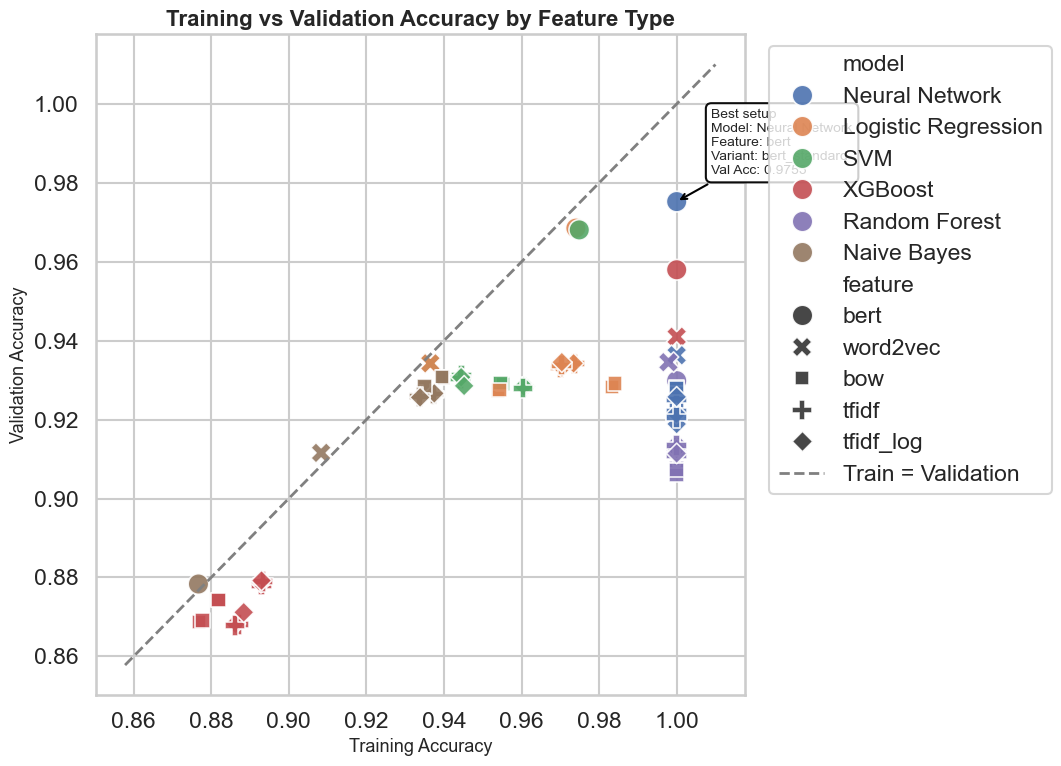

In [37]:
# ---------------------------------------------------------
# CELL 22: TRAINING VS VALIDATION ACCURACY BY FEATURE TYPE
# ---------------------------------------------------------
# This version includes both:
# - classic sparse-text features: bow, tfidf, tfidf_log
# - embedding features: embedding
#
# Color = model family
# Marker shape = feature type

plot_df = viz_df.copy()

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_df,
    x="train_accuracy",
    y="val_accuracy",
    hue="model",
    style="feature",
    s=220,
    alpha=0.9
)

min_val = min(plot_df["train_accuracy"].min(), plot_df["val_accuracy"].min()) - 0.01
max_val = max(plot_df["train_accuracy"].max(), plot_df["val_accuracy"].max()) + 0.01

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    color="gray",
    linewidth=2,
    label="Train = Validation"
)

best_row = plot_df.sort_values("val_accuracy", ascending=False).iloc[0]
best_label = (
    f"Best setup\n"
    f"Model: {best_row['model']}\n"
    f"Feature: {best_row['feature']}\n"
    f"Variant: {best_row['variant']}\n"
    f"Val Acc: {best_row['val_accuracy']:.4f}"
)

plt.annotate(
    best_label,
    xy=(best_row["train_accuracy"], best_row["val_accuracy"]),
    xytext=(25, 20),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.title("Training vs Validation Accuracy by Feature Type", fontsize=16, weight="bold")
plt.xlabel("Training Accuracy", fontsize=13)
plt.ylabel("Validation Accuracy", fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


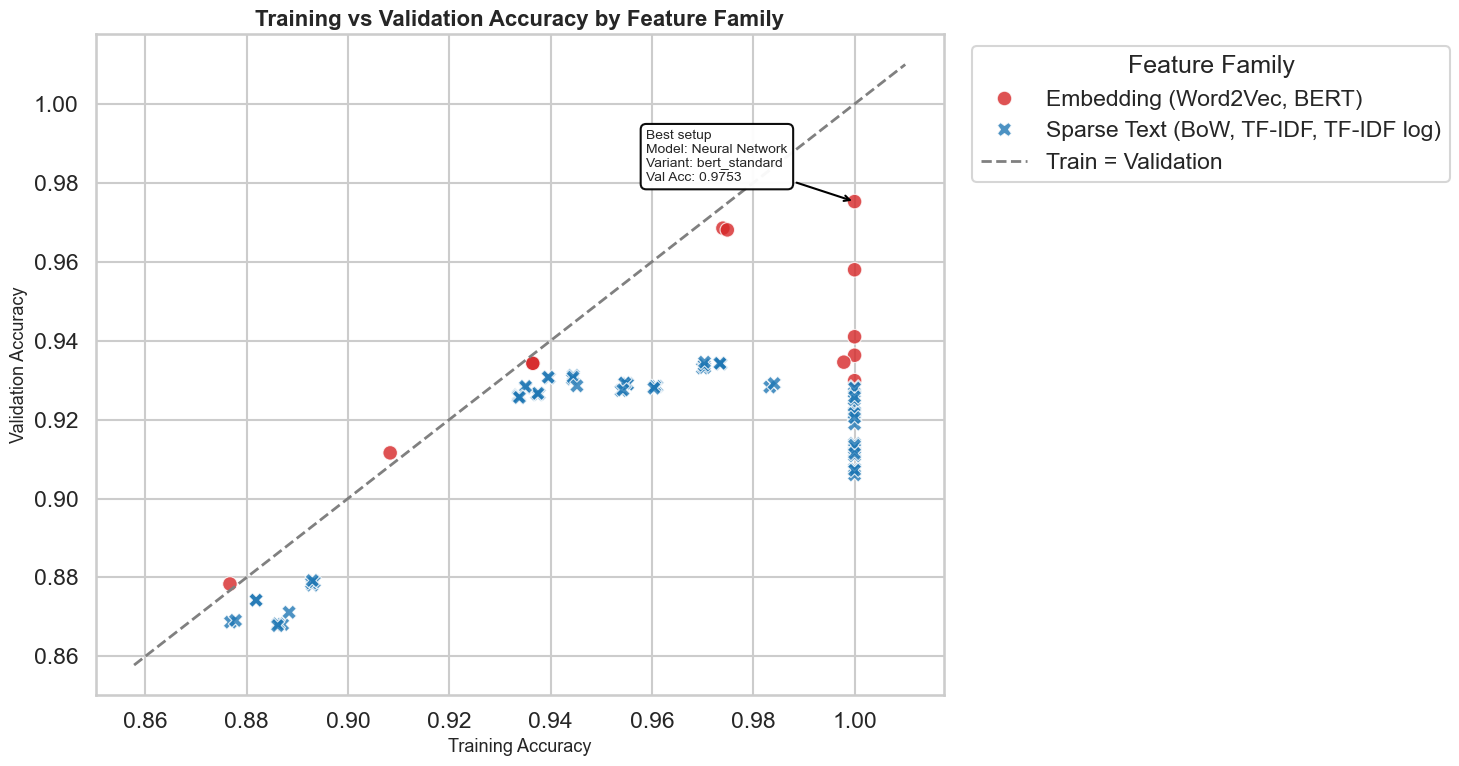

In [59]:
# ---------------------------------------------------------
# CELL 22: TRAINING VS VALIDATION ACCURACY BY FEATURE FAMILY
# ---------------------------------------------------------

plot_df = viz_df.copy()

plot_df["feature_group"] = plot_df["feature_family"].replace({
    "sparse_text": "Sparse Text (BoW, TF-IDF, TF-IDF log)",
    "embedding": "Embedding (Word2Vec, BERT)"
})

family_palette = {
    "Sparse Text (BoW, TF-IDF, TF-IDF log)": "#1f77b4",
    "Embedding (Word2Vec, BERT)": "#d62728"
}

plt.figure(figsize=(15, 8))
sns.scatterplot(
    data=plot_df,
    x="train_accuracy",
    y="val_accuracy",
    hue="feature_group",
    style="feature_group",
    palette=family_palette,
    markers={
        "Sparse Text (BoW, TF-IDF, TF-IDF log)": "X",
        "Embedding (Word2Vec, BERT)": "o"
    },
    s=110,
    alpha=0.8
)

min_val = min(plot_df["train_accuracy"].min(), plot_df["val_accuracy"].min()) - 0.01
max_val = max(plot_df["train_accuracy"].max(), plot_df["val_accuracy"].max()) + 0.01

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    color="gray",
    linewidth=2,
    label="Train = Validation"
)

best_row = plot_df.sort_values("val_accuracy", ascending=False).iloc[0]
best_label = (
    f"Best setup\n"
    f"Model: {best_row['model']}\n"
    f"Variant: {best_row['variant']}\n"
    f"Val Acc: {best_row['val_accuracy']:.4f}"
)


plt.annotate(
    best_label,
    xy=(best_row["train_accuracy"], best_row["val_accuracy"]),
    xytext=(-150, 15),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.title("Training vs Validation Accuracy by Feature Family", fontsize=16, weight="bold")
plt.xlabel("Training Accuracy", fontsize=13)
plt.ylabel("Validation Accuracy", fontsize=13)

plt.legend(
    title="Feature Family",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


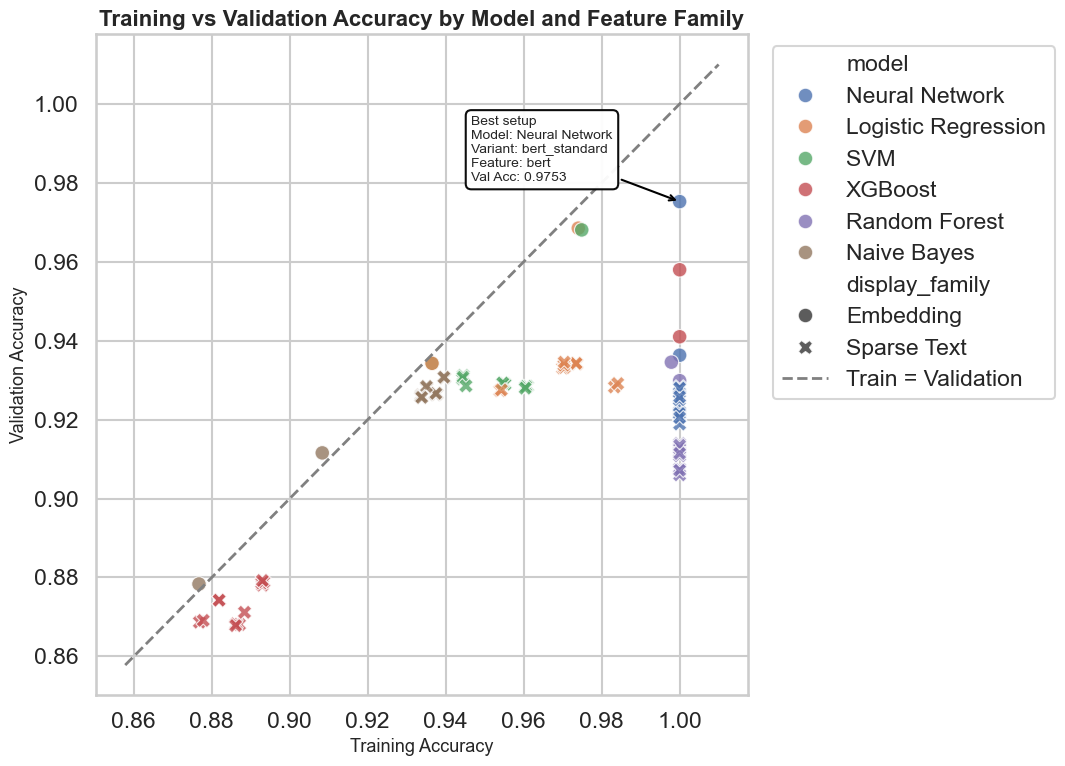

In [47]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=viz_df,
    x="train_accuracy",
    y="val_accuracy",
    hue="model",
    style="display_family",
    s=110,
    alpha=0.8
)

min_val = min(viz_df["train_accuracy"].min(), viz_df["val_accuracy"].min()) - 0.01
max_val = max(viz_df["train_accuracy"].max(), viz_df["val_accuracy"].max()) + 0.01

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    color="gray",
    linewidth=2,
    label="Train = Validation"
)

best_row = viz_df.sort_values("val_accuracy", ascending=False).iloc[0]
best_label = (
    f"Best setup\n"
    f"Model: {best_row['model']}\n"
    f"Variant: {best_row['variant']}\n"
    f"Feature: {best_row['feature']}\n"
    f"Val Acc: {best_row['val_accuracy']:.4f}"
)

plt.annotate(
    best_label,
    xy=(best_row["train_accuracy"], best_row["val_accuracy"]),
    xytext=(-150, 15),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.title("Training vs Validation Accuracy by Model and Feature Family", fontsize=16, weight="bold")
plt.xlabel("Training Accuracy", fontsize=13)
plt.ylabel("Validation Accuracy", fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()


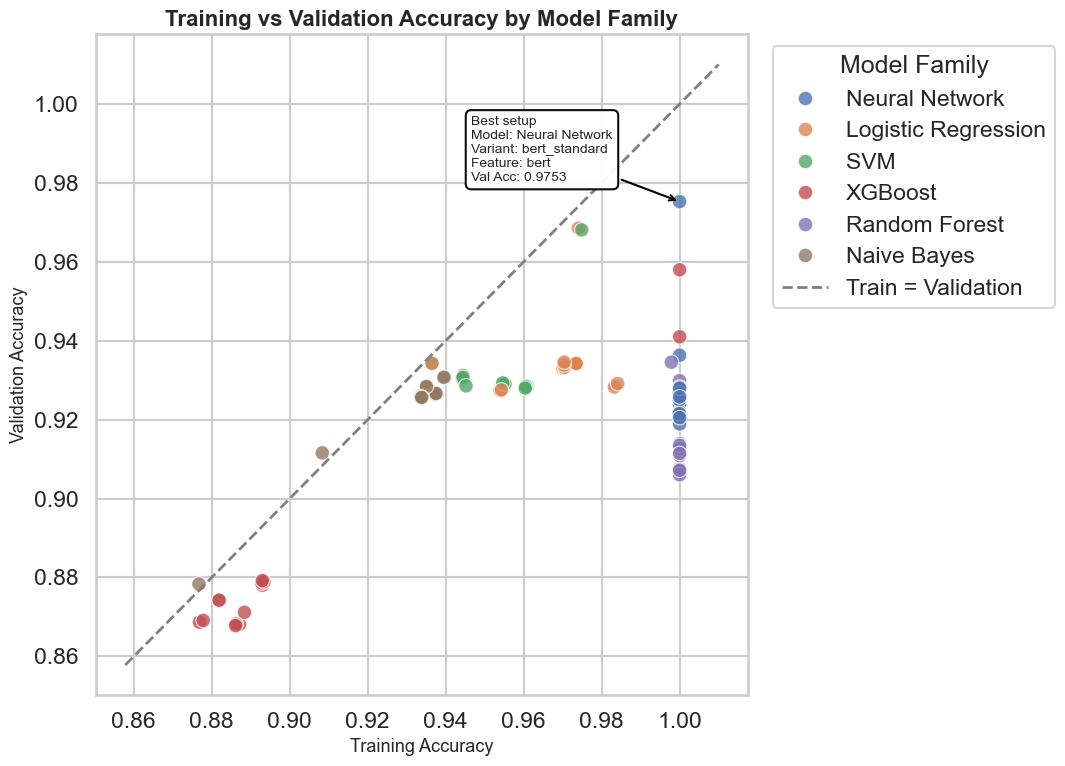

In [48]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=viz_df,
    x="train_accuracy",
    y="val_accuracy",
    hue="model",
    s=110,
    alpha=0.8
)

min_val = min(viz_df["train_accuracy"].min(), viz_df["val_accuracy"].min()) - 0.01
max_val = max(viz_df["train_accuracy"].max(), viz_df["val_accuracy"].max()) + 0.01

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    color="gray",
    linewidth=2,
    label="Train = Validation"
)

best_row = viz_df.sort_values("val_accuracy", ascending=False).iloc[0]
best_label = (
    f"Best setup\n"
    f"Model: {best_row['model']}\n"
    f"Variant: {best_row['variant']}\n"
    f"Feature: {best_row['feature']}\n"
    f"Val Acc: {best_row['val_accuracy']:.4f}"
)

plt.annotate(
    best_label,
    xy=(best_row["train_accuracy"], best_row["val_accuracy"]),
    xytext=(-150, 15),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.title("Training vs Validation Accuracy by Model Family", fontsize=16, weight="bold")
plt.xlabel("Training Accuracy", fontsize=13)
plt.ylabel("Validation Accuracy", fontsize=13)
plt.legend(title="Model Family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()


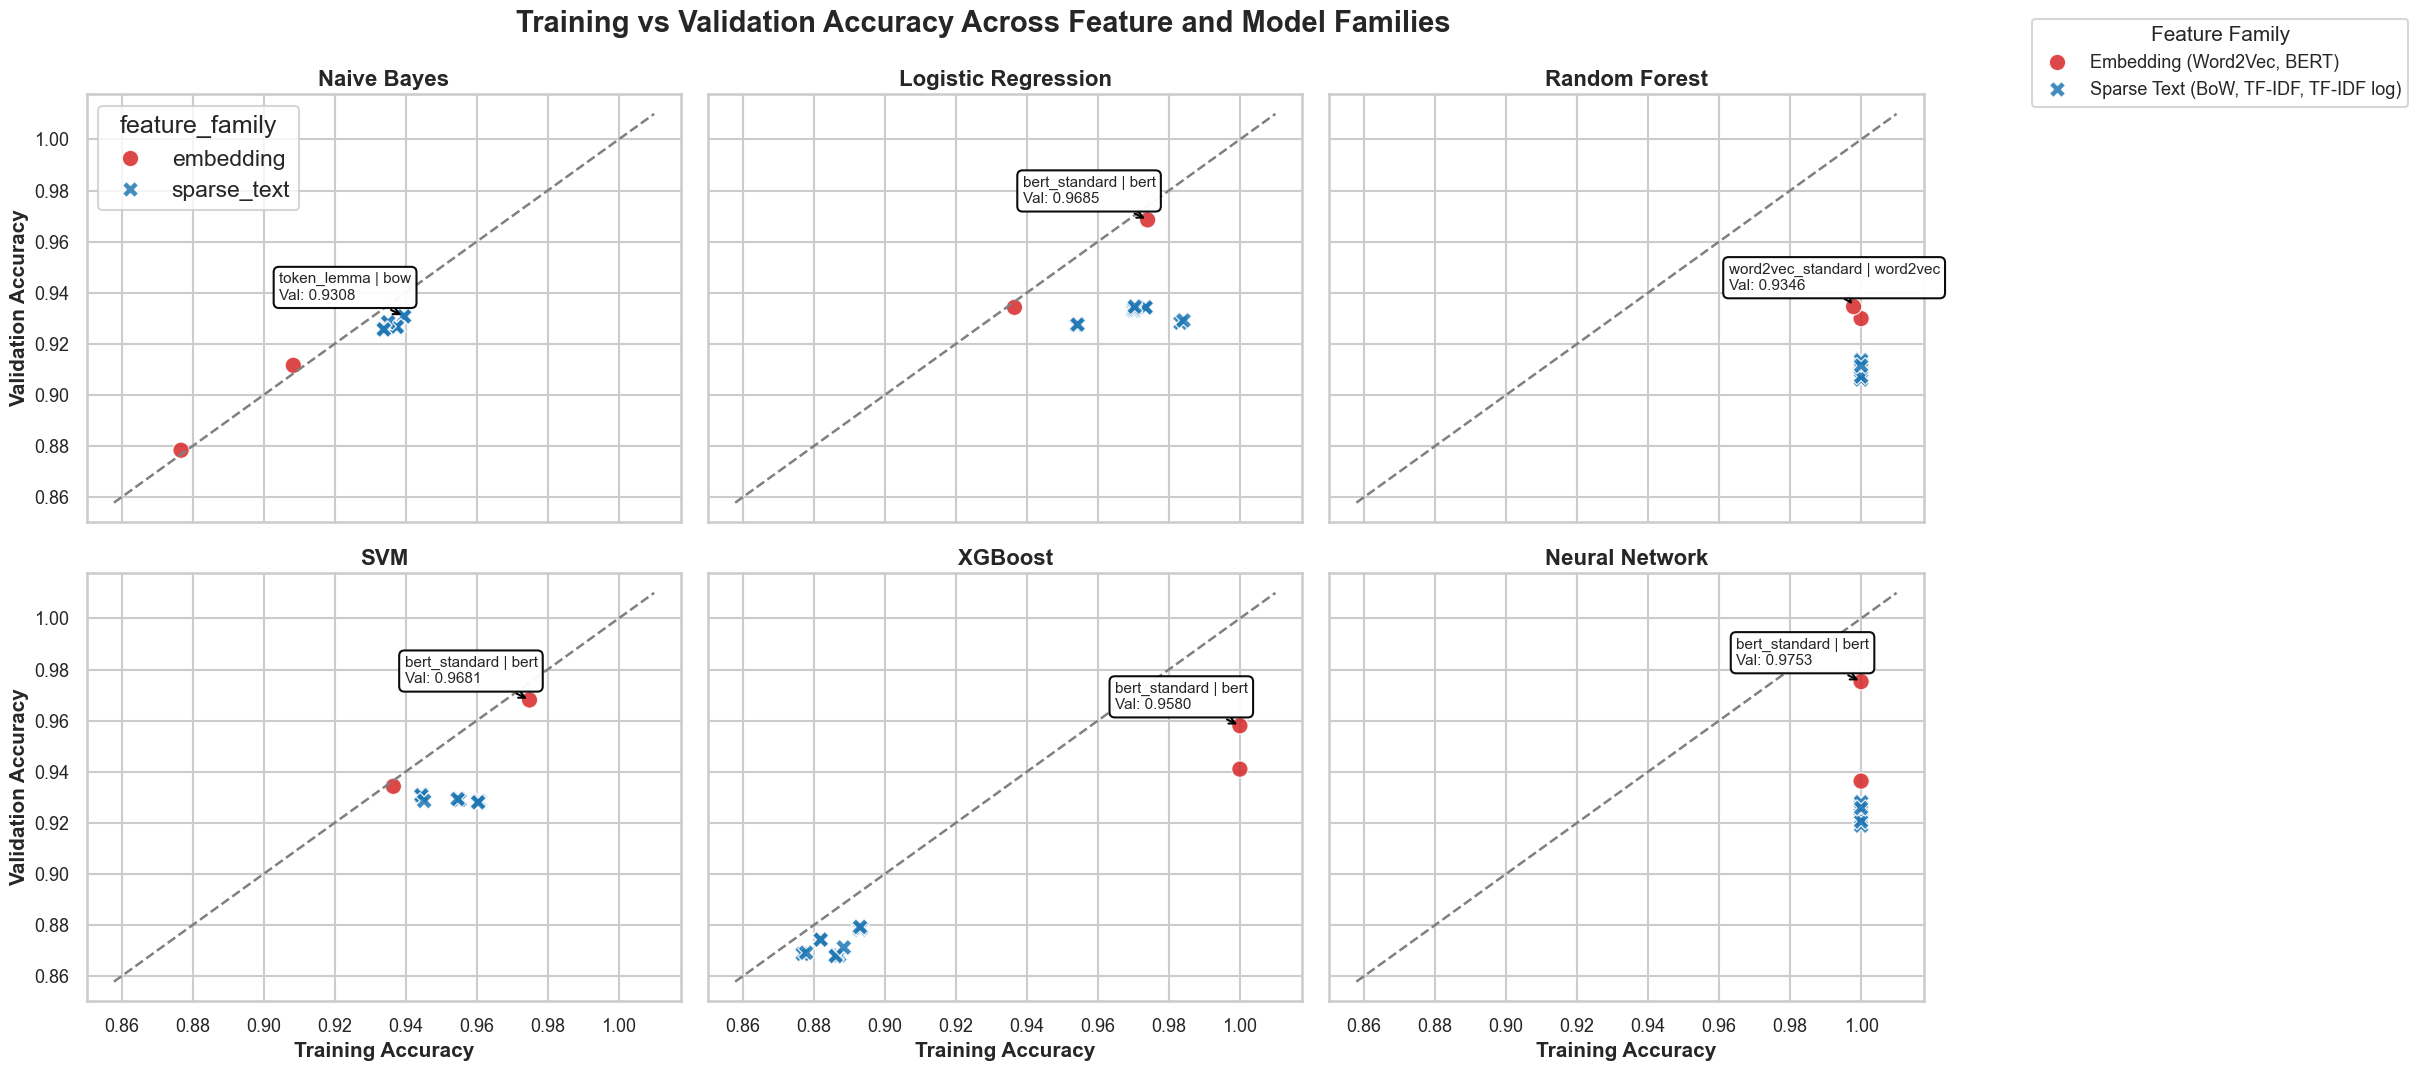

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["Naive Bayes", "Logistic Regression", "Random Forest", "SVM", "XGBoost", "Neural Network"]

fig, axes = plt.subplots(2, 3, figsize=(20, 11), sharex=True, sharey=True)
axes = axes.flatten()

min_val = min(viz_df["train_accuracy"].min(), viz_df["val_accuracy"].min()) - 0.01
max_val = max(viz_df["train_accuracy"].max(), viz_df["val_accuracy"].max()) + 0.01

for ax, model_name in zip(axes, model_order):
    family_df = viz_df[viz_df["model"] == model_name].copy()

    sns.scatterplot(
        data=family_df,
        x="train_accuracy",
        y="val_accuracy",
        hue="feature_family",
        style="feature_family",
        palette={"sparse_text": "#1f77b4", "embedding": "#d62728"},
        markers={"sparse_text": "X", "embedding": "o"},
        s=140,
        alpha=0.85,
        ax=ax
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "--",
        color="gray",
        linewidth=1.8
    )

    best_row = family_df.sort_values("val_accuracy", ascending=False).iloc[0]
    best_label = (
        f"{best_row['variant']} | {best_row['feature']}\n"
        f"Val: {best_row['val_accuracy']:.4f}"
    )

    ax.annotate(
        best_label,
        xy=(best_row["train_accuracy"], best_row["val_accuracy"]),
        xytext=(-90, 12),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.95),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=11
    )

    ax.set_title(model_name, fontsize=16, weight="bold")
    ax.set_xlabel("Training Accuracy", fontsize=15, weight="bold")
    ax.set_ylabel("Validation Accuracy", fontsize=15, weight="bold")
    ax.tick_params(axis="both", labelsize=13)

    if ax != axes[0]:
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["Embedding (Word2Vec, BERT)","Sparse Text (BoW, TF-IDF, TF-IDF log)"],
    title="Feature Family",
    title_fontsize=15,
    fontsize=13,
    bbox_to_anchor=(1.02, 0.98),
    loc="upper left"
)

fig.suptitle("Training vs Validation Accuracy Across Feature and Model Families", fontsize=21, weight="bold")
plt.tight_layout()
plt.show()


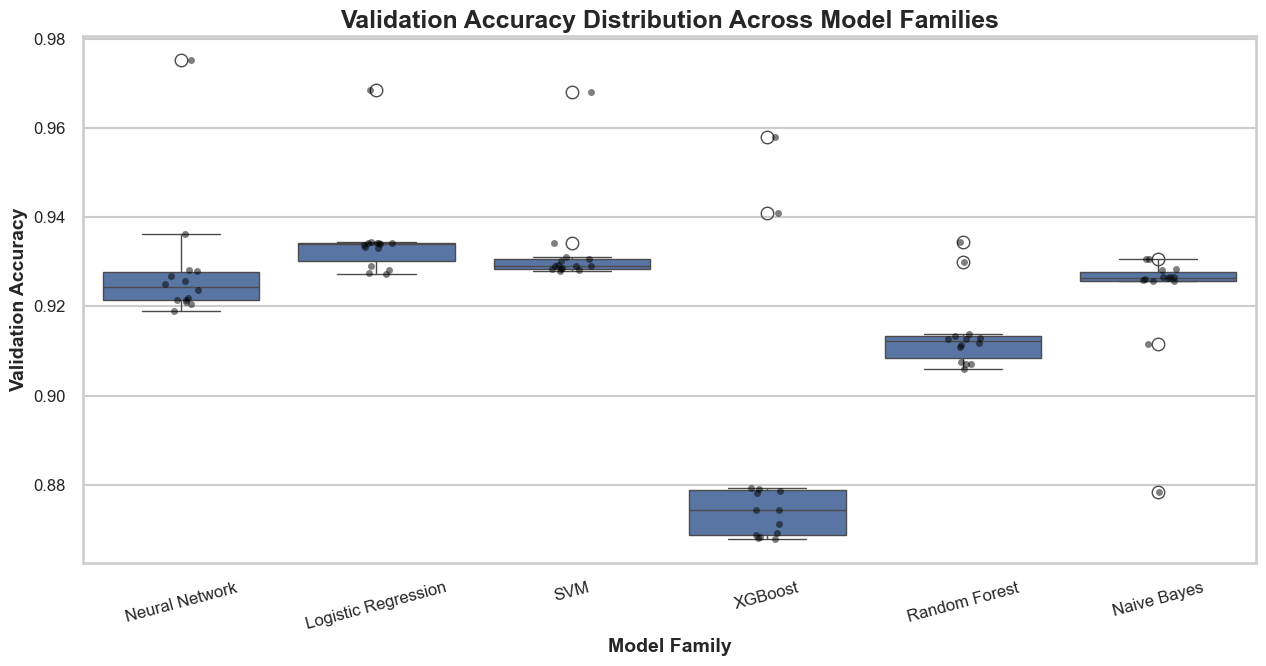

In [62]:
# ---------------------------------------------------------
# CELL 23: VALIDATION ACCURACY DISTRIBUTION BY MODEL FAMILY
# ---------------------------------------------------------
# This version includes both:
# - Sparse Text
# - Embedding

plt.figure(figsize=(13, 7))

sns.boxplot(data=viz_df, x="model", y="val_accuracy")
sns.stripplot(data=viz_df, x="model", y="val_accuracy", color="black", alpha=0.5, size=5)

plt.title("Validation Accuracy Distribution Across Model Families", fontsize=18, weight="bold")
plt.xlabel("Model Family", fontsize=14, weight="bold")
plt.ylabel("Validation Accuracy", fontsize=14, weight="bold")
plt.xticks(rotation=15, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


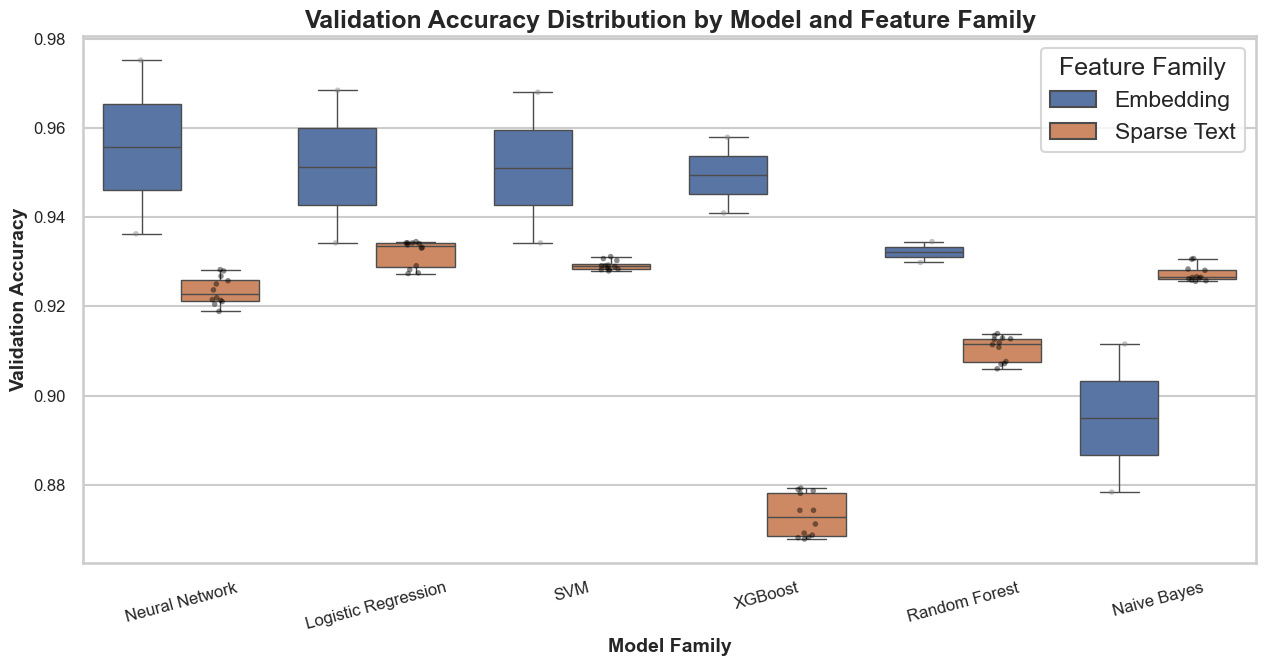

In [63]:
# ---------------------------------------------------------
# CELL 23: VALIDATION ACCURACY DISTRIBUTION BY MODEL FAMILY
# ---------------------------------------------------------
# This version includes both feature families and colors them:
# - Sparse Text
# - Embedding

plot_df = viz_df.copy()
plot_df["feature_group"] = plot_df["feature_family"].replace({
    "sparse_text": "Sparse Text",
    "embedding": "Embedding"
})

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=plot_df,
    x="model",
    y="val_accuracy",
    hue="feature_group"
)

sns.stripplot(
    data=plot_df,
    x="model",
    y="val_accuracy",
    hue="feature_group",
    dodge=True,
    alpha=0.45,
    size=4,
    palette={"Sparse Text": "black", "Embedding": "gray"}
)

plt.title("Validation Accuracy Distribution by Model and Feature Family", fontsize=18, weight="bold")
plt.xlabel("Model Family", fontsize=14, weight="bold")
plt.ylabel("Validation Accuracy", fontsize=14, weight="bold")
plt.xticks(rotation=15, fontsize=12)
plt.yticks(fontsize=12)

# Remove duplicated legends caused by boxplot + stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Feature Family")

plt.tight_layout()
plt.show()


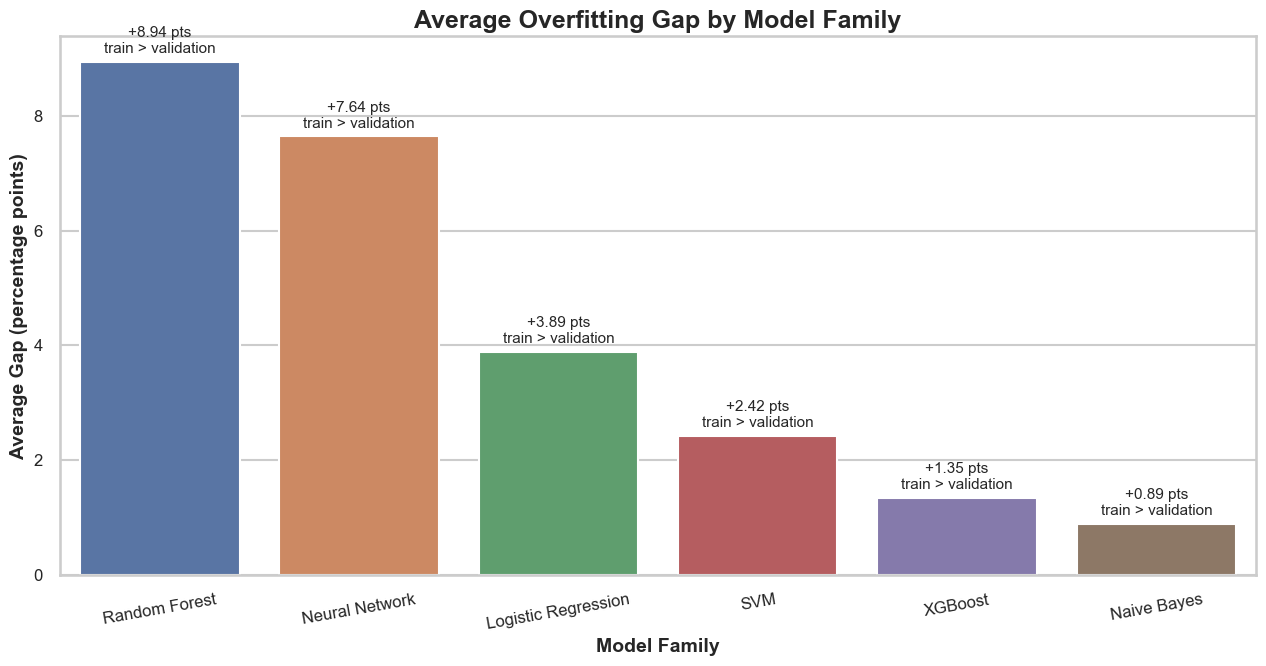

In [60]:
# ---------------------------------------------------------
# CELL 24: AVERAGE TRAIN-VALIDATION ACCURACY GAP BY MODEL FAMILY
# ---------------------------------------------------------
# Higher bars mean more overfitting.
# The value is shown in percentage points.

classic_model_df = viz_df[viz_df["feature_family"] == "sparse_text"].copy()
classic_model_df["overfit_gap_pp"] = (classic_model_df["train_accuracy"] - classic_model_df["val_accuracy"]) * 100

avg_gap = (
    classic_model_df.groupby("model", as_index=False)["overfit_gap_pp"]
    .mean()
    .sort_values("overfit_gap_pp", ascending=False)
)

plt.figure(figsize=(13, 7))
ax = sns.barplot(data=avg_gap, x="model", y="overfit_gap_pp", hue="model", legend=False)

for bar, value in zip(ax.patches, avg_gap["overfit_gap_pp"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    label = f"+{value:.2f} pts\ntrain > validation"
    ax.text(x, y + 0.10, label, ha="center", va="bottom", fontsize=11)

plt.title("Average Overfitting Gap by Model Family", fontsize=18, weight="bold")
plt.xlabel("Model Family", fontsize=14, weight="bold")
plt.ylabel("Average Gap (percentage points)", fontsize=14, weight="bold")
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


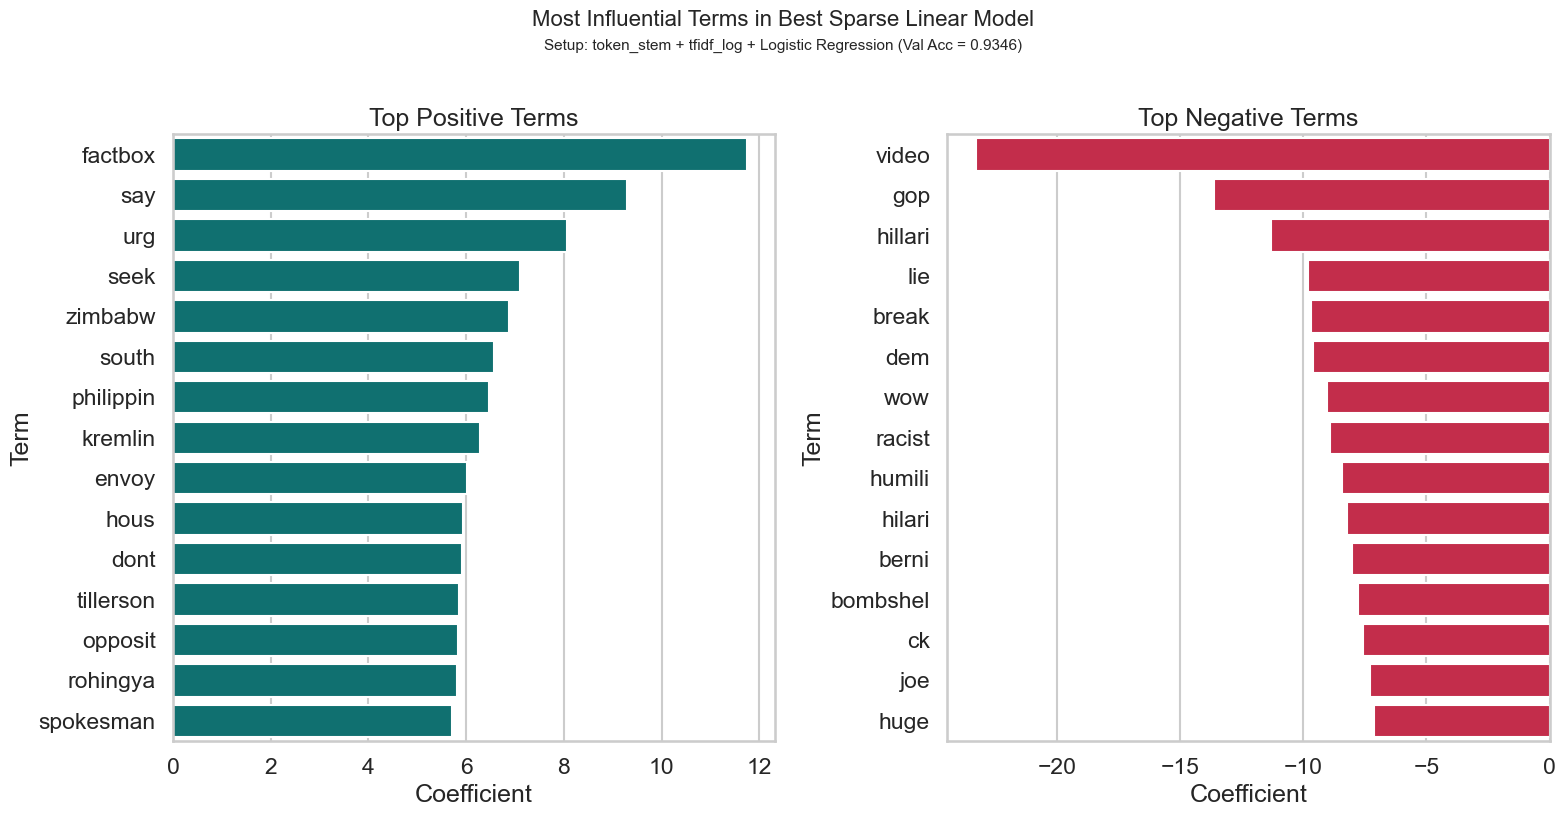

In [61]:
# ---------------------------------------------------------
# CELL 21: MOST INFLUENTIAL TERMS IN THE BEST SPARSE LINEAR MODEL
# ---------------------------------------------------------
# We use the best sparse-text linear model (Logistic Regression or SVM-like linear model)
# because only those models expose word coefficients tied to vectorizer terms.

sparse_linear_df = results_df[
    (results_df["feature_family"] == "sparse_text") &
    (results_df["model"].isin(["Logistic Regression", "SVM"]))
].sort_values(by=["val_accuracy", "best_cv_accuracy"], ascending=False)

if len(sparse_linear_df) == 0:
    print("No sparse linear model was found, so this plot cannot be created.")
else:
    best_linear_row = sparse_linear_df.iloc[0]
    linear_key = (best_linear_row["variant"], best_linear_row["feature"], best_linear_row["model"])
    best_linear_pipeline = best_estimators[linear_key]

    feature_names = best_linear_pipeline.named_steps["vectorizer"].get_feature_names_out()
    model_step = best_linear_pipeline.named_steps["model"]

    if hasattr(model_step, "coef_"):
        coefs = model_step.coef_[0]
        coef_df = pd.DataFrame({"term": feature_names, "coef": coefs})

        top_positive = coef_df.sort_values("coef", ascending=False).head(15)
        top_negative = coef_df.sort_values("coef", ascending=True).head(15)

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        sns.barplot(data=top_positive, x="coef", y="term", ax=axes[0], color="teal")
        axes[0].set_title("Top Positive Terms")
        axes[0].set_xlabel("Coefficient")
        axes[0].set_ylabel("Term")

        sns.barplot(data=top_negative, x="coef", y="term", ax=axes[1], color="crimson")
        axes[1].set_title("Top Negative Terms")
        axes[1].set_xlabel("Coefficient")
        axes[1].set_ylabel("Term")

        setup_text = (
            f"Setup: {best_linear_row['variant']} + {best_linear_row['feature']} + {best_linear_row['model']} "
            f"(Val Acc = {best_linear_row['val_accuracy']:.4f})"
        )

        plt.suptitle("Most Influential Terms in Best Sparse Linear Model", y=1.03, fontsize=16)
        fig.text(0.5, 0.98, setup_text, ha="center", fontsize=11)

        plt.tight_layout()
        plt.show()
    else:
        print("The best sparse linear model does not expose coefficients.")


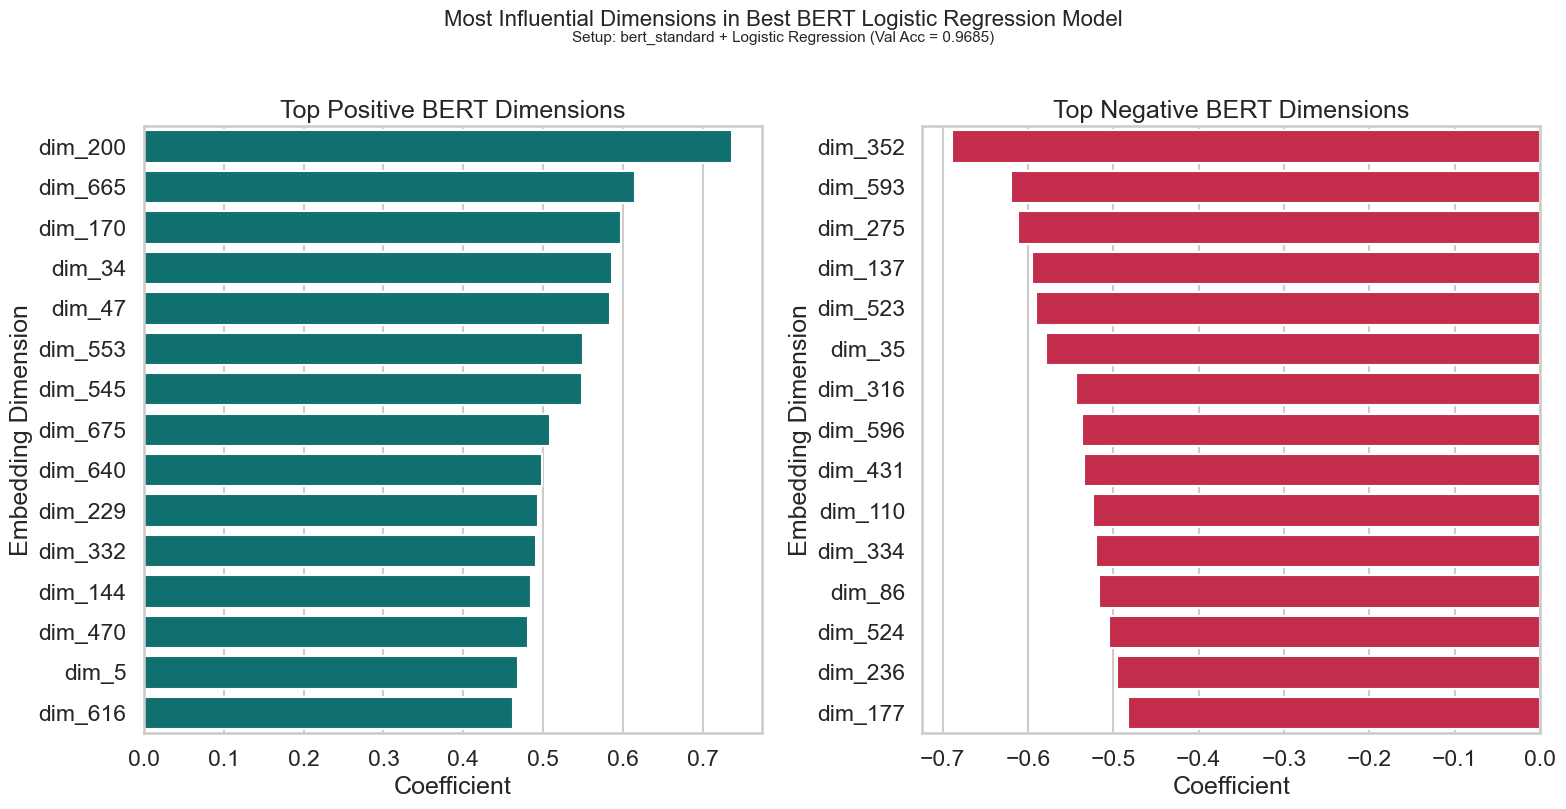

In [77]:
# ---------------------------------------------------------
# MOST INFLUENTIAL BERT EMBEDDING DIMENSIONS
# for the best Logistic Regression embedding model
# ---------------------------------------------------------

# Best Logistic Regression row should already exist
# If not, uncomment and run:
# best_logreg_row = results_df[results_df["model"] == "Logistic Regression"] \
#     .sort_values(by=["val_accuracy", "best_cv_accuracy"], ascending=False) \
#     .iloc[0]

best_logreg_key = (
    best_logreg_row["variant"],
    best_logreg_row["feature"],
    best_logreg_row["model"]
)

best_logreg_pipeline = best_estimators[best_logreg_key]
model_step = best_logreg_pipeline.named_steps["model"]

# Coefficients for embedding dimensions
coefs = model_step.coef_[0]

coef_df = pd.DataFrame({
    "dimension": [f"dim_{i}" for i in range(len(coefs))],
    "coef": coefs
})

top_positive = coef_df.sort_values("coef", ascending=False).head(15)
top_negative = coef_df.sort_values("coef", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(data=top_positive, x="coef", y="dimension", ax=axes[0], color="teal")
axes[0].set_title("Top Positive BERT Dimensions")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Embedding Dimension")

sns.barplot(data=top_negative, x="coef", y="dimension", ax=axes[1], color="crimson")
axes[1].set_title("Top Negative BERT Dimensions")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("Embedding Dimension")

setup_text = (
    f"Setup: {best_logreg_row['variant']} + {best_logreg_row['model']} "
    f"(Val Acc = {best_logreg_row['val_accuracy']:.4f})"
)

plt.suptitle("Most Influential Dimensions in Best BERT Logistic Regression Model", y=1.02, fontsize=16)
fig.text(0.5, 0.98, setup_text, ha="center", fontsize=11)

plt.tight_layout()
plt.show()


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid", context="talk")

# Assume your training dataframe is called: data
# and has columns:
# - label
# - headline

# Optional: readable class names
label_map = {0: "Fake", 1: "Real"}
data["label_name"] = data["label"].map(label_map)

# Create a simple clean text version if needed
data["headline_clean"] = data["headline"].fillna("").astype(str).str.lower().str.strip()

# Basic text-length features
data["char_count"] = data["headline_clean"].apply(len)
data["word_count"] = data["headline_clean"].apply(lambda x: len(x.split()))


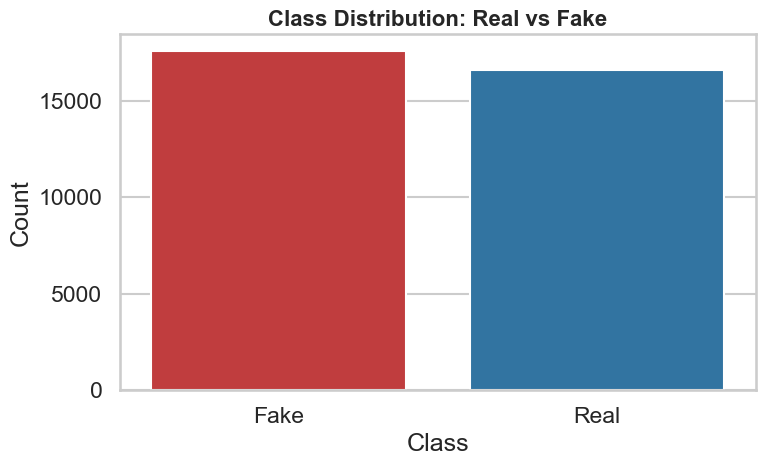

label_name
Fake    17572
Real    16580
Name: count, dtype: int64

Class proportions:
label_name
Fake    0.515
Real    0.485
Name: count, dtype: float64


In [65]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="label_name", hue="label_name", legend=False, palette=["#d62728", "#1f77b4"])
plt.title("Class Distribution: Real vs Fake", fontsize=16, weight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

class_counts = data["label_name"].value_counts()
print(class_counts)
print("\nClass proportions:")
print((class_counts / len(data)).round(3))


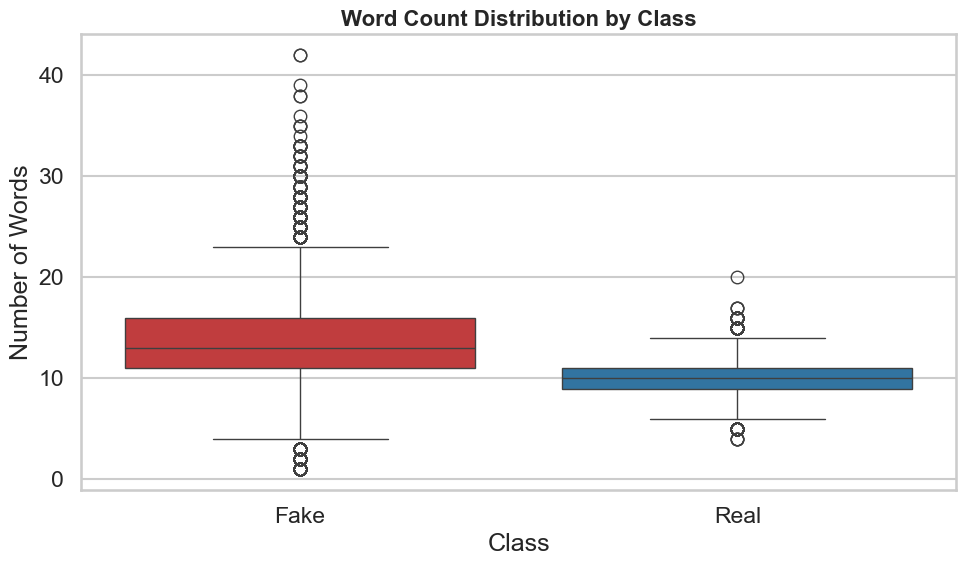

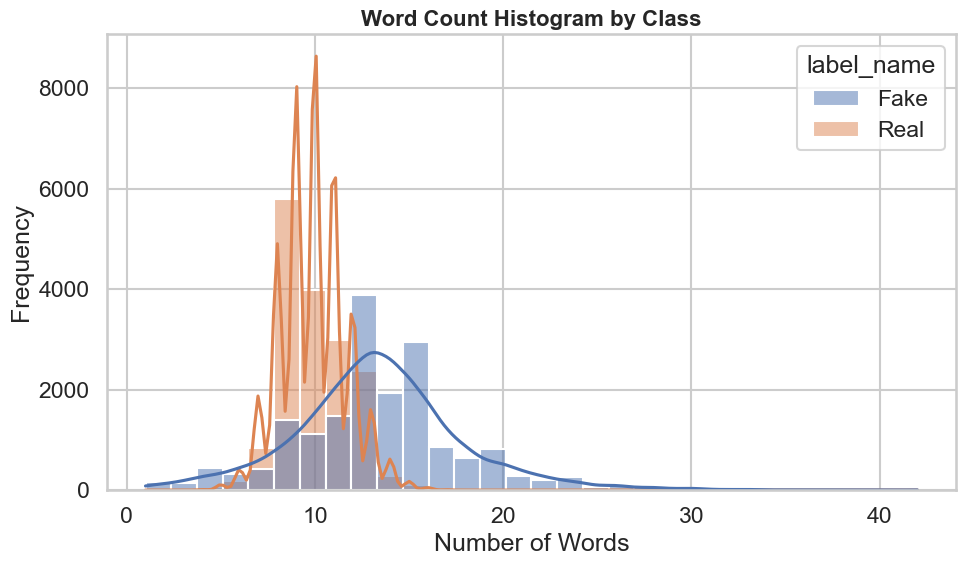

In [66]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="label_name", y="word_count", hue="label_name", legend=False, palette=["#d62728", "#1f77b4"])
plt.title("Word Count Distribution by Class", fontsize=16, weight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="word_count", hue="label_name", bins=30, kde=True, alpha=0.5)
plt.title("Word Count Histogram by Class", fontsize=16, weight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


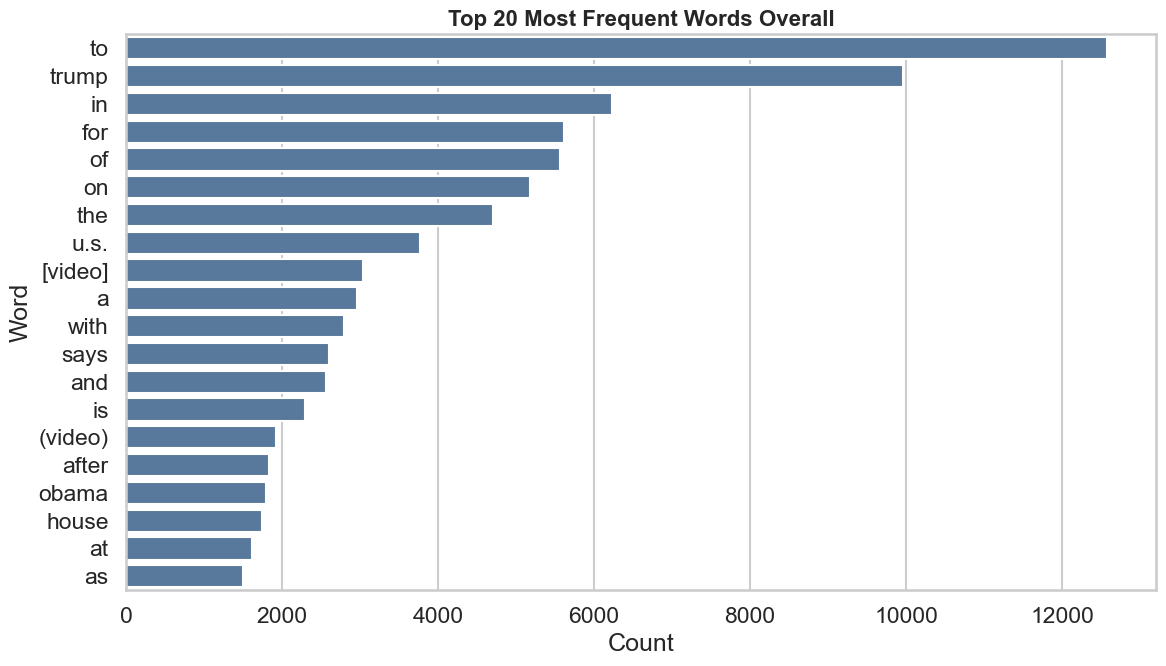

In [68]:
all_words = " ".join(data["headline_clean"]).split()
word_freq = Counter(all_words)

top_words_df = pd.DataFrame(word_freq.most_common(20), columns=["word", "count"])

plt.figure(figsize=(12, 7))
sns.barplot(data=top_words_df, x="count", y="word", color="#4c78a8")
plt.title("Top 20 Most Frequent Words Overall", fontsize=16, weight="bold")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


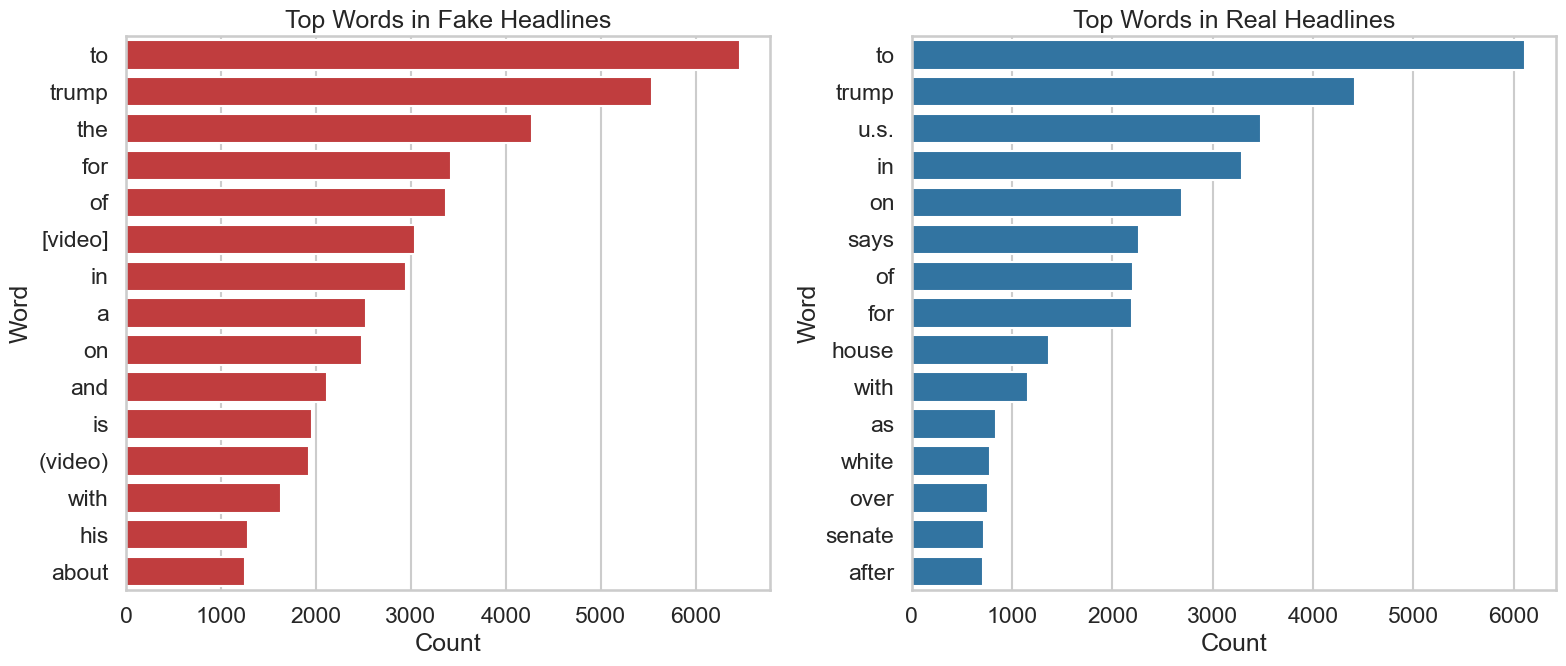

In [69]:
fake_words = " ".join(data.loc[data["label"] == 0, "headline_clean"]).split()
real_words = " ".join(data.loc[data["label"] == 1, "headline_clean"]).split()

fake_top = pd.DataFrame(Counter(fake_words).most_common(15), columns=["word", "count"])
real_top = pd.DataFrame(Counter(real_words).most_common(15), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=fake_top, x="count", y="word", ax=axes[0], color="#d62728")
axes[0].set_title("Top Words in Fake Headlines")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Word")

sns.barplot(data=real_top, x="count", y="word", ax=axes[1], color="#1f77b4")
axes[1].set_title("Top Words in Real Headlines")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.show()
